In [1]:
# Imports
# All libraries needed

import os
import sys
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

# sklearn — used ONLY for validation and comparison
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

# Scratch implementation
sys.path.insert(0, '..')
from src.decision_tree import DecisionTreeScratch, Node

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'stay': '#2ecc71', 'churn': '#e74c3c', 'neutral': '#3498db'}

print('All imports successful ✓')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')

All imports successful ✓
NumPy: 2.5.0
Pandas: 3.0.3


## Load and Prepare the Telco Dataset

In [2]:
# Load the Telco dataset 

DATA_PATH = '../data/Telco-Customer-Churn.csv'

df = pd.read_csv(DATA_PATH)
print(df.head(3))
print(f'Raw dataset: {df.shape[0]:,} rows × {df.shape[1]} columns')

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   
2          No          No              No  Month-to-month              Yes   

      PaymentMethod MonthlyCharges  TotalCharges Churn  
0  E

In [3]:
# Clean the Telco dataset
# 1. Drop customerID: a unique identifier, not a feature
df = df.drop('customerID', axis=1)

# 2. TotalCharges: 11 rows contain ' ' (space) instead of a number
#    pd.to_numeric with errors='coerce' turns those into NaN, then we fill 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0.0)

# 3. Encode target: 'Yes' → 1, 'No' → 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print(f'After cleaning: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Churn rate: {df["Churn"].mean():.1%} ({df["Churn"].sum():,} churners)')
print(f'\nDtypes:\n{df.dtypes.value_counts().to_string()}')

After cleaning: 7,043 rows × 20 columns
Churn rate: 26.5% (1,869 churners)

Dtypes:
str        15
int64       3
float64     2


In [4]:
# Feature Encoding
# Decision Trees don't need feature scaling (no distance or gradient computation)
# BUT they do need numeric input - categoricals need to be encoded

BINARY_COLS = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
BINARY_MAP  = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}

MULTI_CAT_COLS = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod',
]

# Binary encoding
for col in BINARY_COLS:
    df[col] = df[col].map(BINARY_MAP)

# One-hot encoding
#   drop_first=True removes one category per feature to avoid redundancy
#   e.g. Contract has 3 values → we get 2 dummy columns, not 3
df_encoded = pd.get_dummies(df, columns=MULTI_CAT_COLS, drop_first=True, dtype=int)

feature_cols = [c for c in df_encoded.columns if c != 'Churn']
print(f'Features after encoding: {len(feature_cols)}')
print(f'\nAll feature names:')
for i, col in enumerate(feature_cols, 1):
    print(f'  {i:>2}. {col}')

Features after encoding: 30

All feature names:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. PaperlessBilling
   8. MonthlyCharges
   9. TotalCharges
  10. MultipleLines_No phone service
  11. MultipleLines_Yes
  12. InternetService_Fiber optic
  13. InternetService_No
  14. OnlineSecurity_No internet service
  15. OnlineSecurity_Yes
  16. OnlineBackup_No internet service
  17. OnlineBackup_Yes
  18. DeviceProtection_No internet service
  19. DeviceProtection_Yes
  20. TechSupport_No internet service
  21. TechSupport_Yes
  22. StreamingTV_No internet service
  23. StreamingTV_Yes
  24. StreamingMovies_No internet service
  25. StreamingMovies_Yes
  26. Contract_One year
  27. Contract_Two year
  28. PaymentMethod_Credit card (automatic)
  29. PaymentMethod_Electronic check
  30. PaymentMethod_Mailed check


In [5]:
# Train/test split
# IMPORTANT: stratify=y preserves the 26% churn ratio in both splits
# Without stratify, you might randomly get 20% churn in train and 32% in test

X = df_encoded[feature_cols].values
y = df_encoded['Churn'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # preserves class distribution
)

print(f'Train set: {len(X_train):,} samples ({y_train.mean():.1%} churn rate)')
print(f'Test set:  {len(X_test):,} samples  ({y_test.mean():.1%} churn rate)')
print(f'\nNote: Decision Trees do NOT need StandardScaler.')
print('Trees split on raw feature values — scaling has zero effect on predictions.')

Train set: 5,634 samples (26.5% churn rate)
Test set:  1,409 samples  (26.5% churn rate)

Note: Decision Trees do NOT need StandardScaler.
Trees split on raw feature values — scaling has zero effect on predictions.


#### Build the Decision Tree

In [6]:
# Train the Decision Tree
# The DecisionTreeScratch class lives in src/decision_tree.py
# Read that file alongside this notebook 

print('Hyperparameter choices:')
print('  max_depth=8         → Tree can ask at most 8 questions in sequence')
print('  min_samples_split=20 → Don\'t split nodes with < 20 samples')
print('  min_samples_leaf=10  → Each leaf must contain ≥ 10 training samples')
print()
print('Training...')

tree = DecisionTreeScratch(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
)
tree.fit(X_train, y_train)

print(f'\nTree statistics:')
print(f'  Actual depth : {tree.get_depth()}')
print(f'  Total nodes  : {tree.count_nodes()}')
print(f'  n_features   : {tree.n_features_}')
print(f'  n_classes    : {tree.n_classes_}')

Hyperparameter choices:
  max_depth=8         → Tree can ask at most 8 questions in sequence
  min_samples_split=20 → Don't split nodes with < 20 samples
  min_samples_leaf=10  → Each leaf must contain ≥ 10 training samples

Training...

Tree statistics:
  Actual depth : 8
  Total nodes  : 307
  n_features   : 30
  n_classes    : 2


In [7]:
# Print the learned decision rules (top 4 levels)
# Key advantage of decision trees: you can READ the model

print('Decision Rules Learned from the Telco Data:')
print('=' * 60)
print()
tree.print_tree(feature_names=feature_cols, max_print_depth=4)
print()
print('Reading guide:')
print('  [D=N] = depth level N')
print('  <= threshold → go to left child (condition is True)')
print('  > threshold  → go to right child (condition is False)')
print('  LEAF → final prediction for samples reaching this node')

Decision Rules Learned from the Telco Data:

[D=0] tenure <= 16.00  (gini=0.390, n=5634)
│   ├── [D=1] InternetService_Fiber optic <= 0.00  (gini=0.495, n=2042)
│   │   ├── [D=2] tenure <= 3.00  (gini=0.403, n=1174)
│   │   │   ├── [D=3] InternetService_No <= 0.00  (gini=0.484, n=492)
│   │   │   │   ├── [D=4] MonthlyCharges <= 60.15  (gini=0.500, n=292)
│   │   │   │   ├── [D=4] TotalCharges <= 33.20  (gini=0.390, n=200)
│   │   │   ├── [D=3] InternetService_No <= 0.00  (gini=0.303, n=682)
│   │   │   │   ├── [D=4] PaymentMethod_Electronic check <= 0.00  (gini=0.390, n=400)
│   │   │   │   ├── [D=4] Contract_Two year <= 0.00  (gini=0.138, n=282)
│   │   ├── [D=2] TotalCharges <= 119.75  (gini=0.433, n=868)
│   │   │   ├── [D=3] MonthlyCharges <= 69.90  (gini=0.248, n=193)
│   │   │   │   ├── [D=4] LEAF → class=1 (churn)  (n=33)
│   │   │   │   ├── [D=4] TotalCharges <= 75.55  (gini=0.289, n=160)
│   │   │   ├── [D=3] MultipleLines_Yes <= 0.00  (gini=0.464, n=675)
│   │   │   │   ├── [

#### Evaluation

In [8]:
# Make predictions and build the confusion matrix

y_pred_train = tree.predict(X_train)
y_pred_test  = tree.predict(X_test)
y_proba_test = tree.predict_proba(X_test)[:, 1]  # probability of churn

# ── Manual confusion matrix ──────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)
TN, FP, FN, TP = cm.ravel()

print('Confusion Matrix (Test Set)')
print(f'  True Negatives  (TN): {TN:>4}  ← Predicted stay, actually stayed (correct ✓)')
print(f'  False Positives (FP): {FP:>4}  ← Predicted churn, actually stayed (wasted offer ✗)')
print(f'  False Negatives (FN): {FN:>4}  ← Predicted stay, actually churned (MISSED churner ✗✗)')
print(f'  True Positives  (TP): {TP:>4}  ← Predicted churn, actually churned (correct ✓)')

# ── Compute each metric manually ─────────────────────────────────────
accuracy  = (TP + TN) / (TP + TN + FP + FN)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f'\nMetrics (computed manually):')
print(f'  Accuracy  = ({TP}+{TN})/({TP}+{TN}+{FP}+{FN}) = {accuracy:.4f}')
print(f'  Precision = {TP}/({TP}+{FP}) = {precision:.4f}  ({TP} caught / {TP+FP} flagged)')
print(f'  Recall    = {TP}/({TP}+{FN}) = {recall:.4f}  ({TP} caught / {TP+FN} actual churners)')
print(f'  F1-Score  = 2×{precision:.3f}×{recall:.3f} / ({precision:.3f}+{recall:.3f}) = {f1:.4f}')

Confusion Matrix (Test Set)
  True Negatives  (TN):  882  ← Predicted stay, actually stayed (correct ✓)
  False Positives (FP):  153  ← Predicted churn, actually stayed (wasted offer ✗)
  False Negatives (FN):  158  ← Predicted stay, actually churned (MISSED churner ✗✗)
  True Positives  (TP):  216  ← Predicted churn, actually churned (correct ✓)

Metrics (computed manually):
  Accuracy  = (216+882)/(216+882+153+158) = 0.7793
  Precision = 216/(216+153) = 0.5854  (216 caught / 369 flagged)
  Recall    = 216/(216+158) = 0.5775  (216 caught / 374 actual churners)
  F1-Score  = 2×0.585×0.578 / (0.585+0.578) = 0.5814


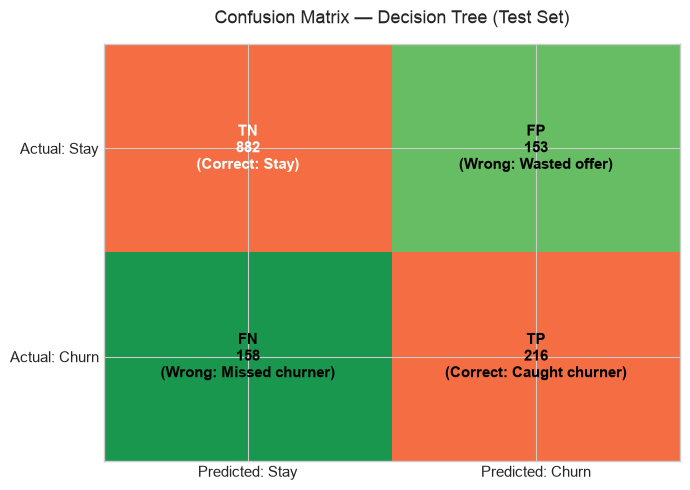

In [10]:
# Visualise the confusion matrix

fig, ax = plt.subplots(figsize=(7, 5))

# Build annotated confusion matrix
labels = np.array([
    [f'TN\n{TN}\n(Correct: Stay)', f'FP\n{FP}\n(Wrong: Wasted offer)'],
    [f'FN\n{FN}\n(Wrong: Missed churner)', f'TP\n{TP}\n(Correct: Caught churner)'],
])

# Colour: greens for correct (diagonal), reds for errors (off-diagonal)
colours = np.array([[0.2, 0.8], [0.9, 0.2]])  # 0=red, 1=green

im = ax.imshow(colours, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

for i in range(2):
    for j in range(2):
        ax.text(j, i, labels[i, j], ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if (i==0 and j==0) else 'black')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Predicted: Stay', 'Predicted: Churn'], fontsize=11)
ax.set_yticklabels(['Actual: Stay', 'Actual: Churn'], fontsize=11)
ax.set_title('Confusion Matrix — Decision Tree (Test Set)', fontsize=13, pad=15)

plt.tight_layout()
plt.savefig('../visualisations/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Importance
Decision Trees give us a natural way to rank features: **how much did each feature reduce Gini Impurity across all splits?**

Features used higher up in the tree (where more samples pass through) and with larger information gain score higher.

In [11]:
# Feature importance — which features drive churn predictions?

importance_df = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : tree.feature_importances_
}).sort_values('importance', ascending=False)

# Only show features the tree actually used
importance_df = importance_df[importance_df['importance'] > 0].reset_index(drop=True)

print(f'Features used by the tree: {len(importance_df)} of {len(feature_cols)}')
print(f'Features ignored: {len(feature_cols) - len(importance_df)}')
print()
print(f'{"Rank":<5} {"Feature":<45} {"Importance":<12} Bar')
print('-' * 80)
for i, row in importance_df.head(15).iterrows():
    bar = '█' * int(row['importance'] * 200)
    print(f'{i+1:<5} {row["feature"]:<45} {row["importance"]:.4f}       {bar}')

Features used by the tree: 22 of 30
Features ignored: 8

Rank  Feature                                       Importance   Bar
--------------------------------------------------------------------------------
1     tenure                                        0.3404       ████████████████████████████████████████████████████████████████████
2     InternetService_Fiber optic                   0.2776       ███████████████████████████████████████████████████████
3     TotalCharges                                  0.0871       █████████████████
4     MonthlyCharges                                0.0798       ███████████████
5     InternetService_No                            0.0295       █████
6     PaymentMethod_Electronic check                0.0292       █████
7     Contract_Two year                             0.0211       ████
8     MultipleLines_Yes                             0.0183       ███
9     Contract_One year                             0.0170       ███
10    PaperlessBilling  

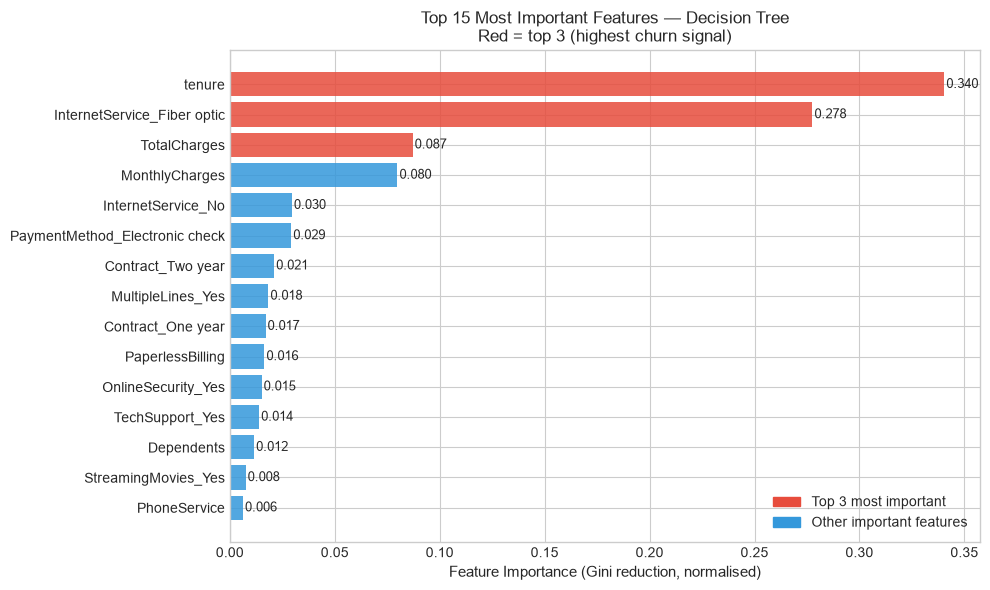


Business insight: features at the top of this chart are the
strongest predictors of churn. These should inform retention strategy.


In [12]:
# Feature importance bar chart

top_n = 15
top_features = importance_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    range(top_n),
    top_features['importance'],
    color=[COLORS['churn'] if i < 3 else COLORS['neutral'] for i in range(top_n)],
    alpha=0.85
)

# Label bars
for i, (_, row) in enumerate(top_features.iterrows()):
    ax.text(row['importance'] + 0.001, i, f"{row['importance']:.3f}",
            va='center', fontsize=9)

ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini reduction, normalised)', fontsize=11)
ax.set_title(f'Top {top_n} Most Important Features — Decision Tree\n'
             'Red = top 3 (highest churn signal)', fontsize=12)

# Add legend
red_patch   = mpatches.Patch(color=COLORS['churn'],   label='Top 3 most important')
blue_patch  = mpatches.Patch(color=COLORS['neutral'], label='Other important features')
ax.legend(handles=[red_patch, blue_patch], loc='lower right')

plt.tight_layout()
plt.savefig('../visualisations/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nBusiness insight: features at the top of this chart are the')
print('strongest predictors of churn. These should inform retention strategy.')